In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time

In [2]:
df = pd.read_csv("K:\PYTHON\MACHINE LEARNING\Fortress_Of_Code\DEEP LEARNING\ANN\DATASETS\Churn_Modelling.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\user\AppData\Local\Temp\ipykernel_10140\2963064938.py:1: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("K:\PYTHON\MACHINE LEARNING\Fortress_Of_Code\DEEP LEARNING\ANN\DATASETS\Churn_Modelling.csv")


In [3]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6332,6333,15793046,Holden,619,France,Female,35,4,90413.12,1,1,1,20555.21,0
9361,9362,15641773,Browne,580,Germany,Male,45,2,179334.83,2,1,1,169303.65,0
3964,3965,15714981,Sabbatini,476,France,Male,37,4,0.00,1,1,1,55775.84,1
8854,8855,15630857,Wu,674,Spain,Female,39,6,0.00,2,1,1,9574.83,0
7046,7047,15737627,Rivero,589,Germany,Female,20,2,121093.29,2,1,0,3529.72,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.sample(5)['Gender']

7517      Male
4635    Female
1539      Male
6854      Male
8173      Male
Name: Gender, dtype: object

<h2><b>Geography column</b><h2>
<h4>From the analysis we find that there are three categories of Geography values namely <b>France, Germany and Spain</b></h4>

<h2><b>Tenure column</b><h2>
<h4>From the analysis we find that there are 10 unique values under the tenure column which shows how long the customer has been there the value in the column ranges from <b>0 to 10</b>, so there are basically <b>11 unique values</b></h4>

In [7]:
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [8]:
df.duplicated().sum()

# There is no duplicate entry in the database so we can move forward to removing useless columns for our problem

np.int64(0)

In [9]:
# Removing the useless columns

df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# Doing one hot encoding for the Geography and Gender columns

df = pd.get_dummies(df, ['Geography', 'Gender'], drop_first=True)

In [12]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [13]:
X = df.drop(columns=['Exited'])
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [14]:
X_train.shape

(8000, 11)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
print(X_test_scaled)

[[-1.03768121  0.77498705 -1.0482813  ... -0.58312392 -0.57273139
   0.91509065]
 [ 0.30708683 -0.46686456 -0.70174202 ... -0.58312392 -0.57273139
   0.91509065]
 [-1.23422423  0.29735181 -1.0482813  ... -0.58312392 -0.57273139
  -1.09278791]
 ...
 [-0.86182692 -0.46686456  1.72403288 ... -0.58312392  1.74601919
   0.91509065]
 [-0.30323097 -0.84897275 -1.0482813  ...  1.71490137 -0.57273139
  -1.09278791]
 [ 0.04847759  1.25262228  1.3774936  ...  1.71490137 -0.57273139
   0.91509065]]


In [17]:
model = Sequential()

model.add(Dense(11, activation="relu", input_dim = 11))
model.add(Dense(11, activation="relu"))
model.add(Dense(1, activation="sigmoid"))


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [20]:
X_train_scaled_np = np.array(X_train_scaled)
y_train_np = np.array(y_train)
curr_time = time.time()
history = model.fit(X_train_scaled_np, y_train_np, epochs=100, validation_split=0.2)
print('\n', time.time()-curr_time)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7823 - loss: 0.5444 - val_accuracy: 0.7975 - val_loss: 0.4781
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8002 - loss: 0.4520 - val_accuracy: 0.8044 - val_loss: 0.4452
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8080 - loss: 0.4344 - val_accuracy: 0.8100 - val_loss: 0.4360
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8188 - loss: 0.4261 - val_accuracy: 0.8156 - val_loss: 0.4294
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8253 - loss: 0.4187 - val_accuracy: 0.8213 - val_loss: 0.4229
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8289 - loss: 0.4110 - val_accuracy: 0.8244 - val_loss: 0.4174
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8328 - loss: 0.4051 - val_accuracy: 0.8244 - val_loss: 0.4120
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8334 - loss: 0.3999 - val_accu

In [21]:
model.layers[0].get_weights()

[array([[ 0.01139245,  0.1770181 , -0.16604255, -0.12210605, -0.03167719,
         -0.17645325,  0.08161189, -0.30608368, -0.00337013, -0.12207023,
         -0.08904769],
        [ 0.6461016 , -0.04661737, -0.80469346,  0.7441999 ,  0.1138391 ,
          0.02709243, -0.17257918,  1.031114  , -0.31294003,  0.14497283,
          0.85396785],
        [ 0.17837468, -0.5618592 ,  0.05797186,  0.13632643,  0.08190555,
          0.13237704, -0.20990708, -0.12341446,  0.06723946,  0.13624965,
          0.0910392 ],
        [-0.1350126 , -0.35468844, -0.03072961, -0.38915315,  0.00986254,
         -0.45616224, -0.34176126, -0.26195604, -0.3733507 ,  0.15489955,
          0.19018814],
        [-0.29883623, -0.10504897, -0.46947736, -0.94314486, -0.3629641 ,
         -0.23009977, -1.3135828 , -0.29824916, -0.28181913, -0.2898479 ,
          1.107678  ],
        [ 0.28670233,  0.0874707 ,  0.39478922,  0.06595231,  0.24531034,
         -0.00134553,  0.19533384, -0.21114494,  0.19377415, -0.5004661

In [22]:
model.layers[1].get_weights()

[array([[-0.49744987,  0.9823256 , -0.3904936 , -1.0016519 ,  0.21462116,
         -0.3943152 , -0.4355872 , -0.7693986 , -0.2900186 , -0.24156915,
          0.32540166],
        [-0.05505772, -0.25164783, -0.04158076,  0.52234715,  0.12733106,
         -0.20369315, -0.24632291,  0.45845994,  0.3452888 ,  0.0677769 ,
          0.25235942],
        [-0.92432106,  0.14025535, -0.15777522, -0.19287777,  0.28656736,
          0.1226328 ,  0.3528896 , -0.77461475,  0.54426384, -0.8589677 ,
          0.04674944],
        [ 0.24253698, -0.37381685, -0.03138269,  0.29771382, -0.05686074,
         -0.04933719,  0.41947487, -0.97753435, -0.6473829 , -0.18664114,
         -0.25428894],
        [-0.6312653 , -0.01227021,  0.25480857, -0.5058542 ,  0.5509537 ,
         -0.07201604,  0.38427413, -0.05880978,  0.12242462, -0.0671047 ,
          0.14173077],
        [-0.10728031, -0.19981135,  0.13353494,  0.37900355,  0.2542911 ,
          0.26994994, -0.06261744, -0.32733998,  0.5904006 ,  0.7294173

In [23]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step


In [24]:
y_pred = np.where(y_log>0.5, 1, 0)

In [25]:
accuracy_score(y_test, y_pred)

0.8645

In [26]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

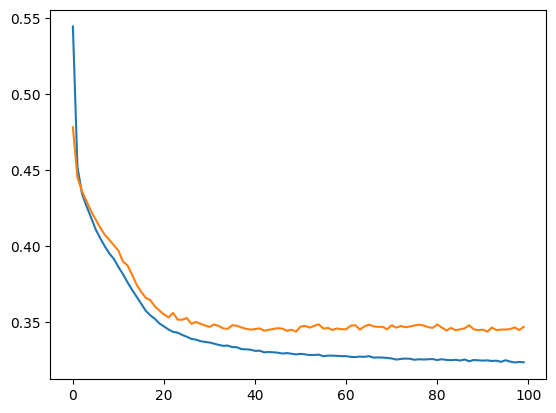

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

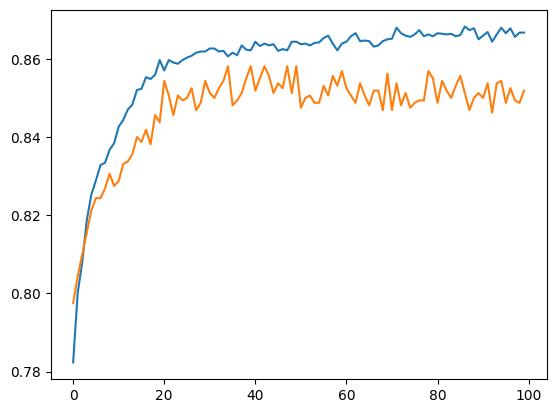

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [29]:

print(tensorflow.__version__)
print(tensorflow.config.list_physical_devices('GPU'))


2.21.0
[]
